# Correlation Analysis

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/muhammadtalhaishtiaq/ai-orchestrator/blob/main/02-exploratory-data-analysis/04_correlation_analysis.ipynb)


---

## What are we learning?

Correlation analysis measures the strength and direction of the linear relationship between two numerical variables. In this notebook you will compute, visualise and interpret correlations using real data.

## The idea in plain English

Imagine you record daily ice-cream sales and daily temperature. If sales tend to rise when temperature rises, the two variables move together. Correlation quantifies this co-movement on a scale from –1 (perfect opposite movement) to +1 (perfect together movement), with 0 meaning no linear pattern.

## Setup

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")
print('Setup done!')

Setup done!


## Step 1 — Load data

In [2]:
# Classic Boston housing dataset (toy data built into seaborn)
boston = sns.load_dataset('mpg').dropna()
boston = boston.rename(columns={'mpg':'fuel_efficiency'})
print(boston.head())

   fuel_efficiency  cylinders  displacement  horsepower  weight  acceleration  \
0             18.0          8         307.0       130.0    3504          12.0   
1             15.0          8         350.0       165.0    3693          11.5   
2             18.0          8         318.0       150.0    3436          11.0   
3             16.0          8         304.0       150.0    3433          12.0   
4             17.0          8         302.0       140.0    3449          10.5   

   model_year origin                       name  
0          70    usa  chevrolet chevelle malibu  
1          70    usa          buick skylark 320  
2          70    usa         plymouth satellite  
3          70    usa              amc rebel sst  
4          70    usa                ford torino  


## Step 2 — Apply Correlation Analysis

In [3]:
# Select numeric columns for correlation
numeric_cols = boston.select_dtypes(include=np.number)
corr_matrix = numeric_cols.corr(method='pearson')
print("Correlation matrix shape:", corr_matrix.shape)
corr_matrix.style.background_gradient(cmap='coolwarm', axis=None)

Correlation matrix shape: (7, 7)


,fuel_efficiency,cylinders,displacement,horsepower,weight,acceleration,model_year
fuel_efficiency,1.000000,-0.777618,-0.805127,-0.778427,-0.832244,0.423329,0.580541
cylinders,-0.777618,1.000000,0.950823,0.842983,0.897527,-0.504683,-0.345647
displacement,-0.805127,0.950823,1.000000,0.897257,0.932994,-0.543800,-0.369855
horsepower,-0.778427,0.842983,0.897257,1.000000,0.864538,-0.689196,-0.416361
weight,-0.832244,0.897527,0.932994,0.864538,1.000000,-0.416839,-0.309120
acceleration,0.423329,-0.504683,-0.543800,-0.689196,-0.416839,1.000000,0.290316
model_year,0.580541,-0.345647,-0.369855,-0.416361,-0.309120,0.290316,1.000000


## Step 3 — Visualise

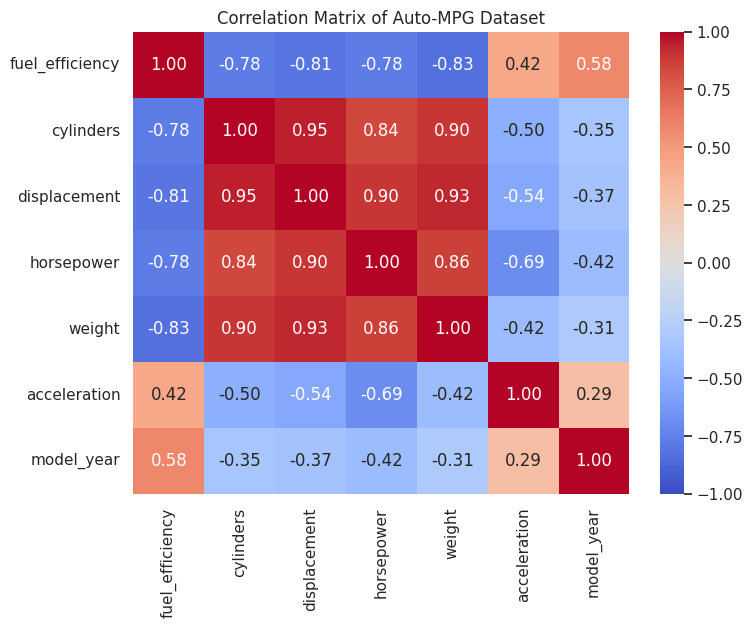

In [4]:
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix of Auto-MPG Dataset')
plt.show()

## Results & interpretation

In [5]:
# Focus on fuel efficiency correlations
fe_corr = corr_matrix['fuel_efficiency'].sort_values(key=abs, ascending=False)
print("Variables most correlated with fuel_efficiency:")
print(fe_corr)
print("\nStrong negative correlation with horsepower:", fe_corr['horsepower'])

Variables most correlated with fuel_efficiency:
fuel_efficiency    1.000000
weight            -0.832244
displacement      -0.805127
horsepower        -0.778427
cylinders         -0.777618
model_year         0.580541
acceleration       0.423329
Name: fuel_efficiency, dtype: float64

Strong negative correlation with horsepower: -0.7784267838977761


## Summary

- Correlation ranges from –1 to +1 and gauges linear relationships.
- A heatmap quickly reveals which variable pairs move together or opposite.
- In our data, `horsepower` has a strong negative correlation with `fuel_efficiency`, suggesting cars with more horsepower tend to consume more fuel.
- Correlation does not imply causation; it only flags patterns worth deeper investigation.

## Exercises

1. Compute Spearman correlation for `fuel_efficiency` vs `horsepower` and compare with Pearson.
2. Create a scatter plot with regression line for the pair with the highest absolute correlation.
3. Drop any one redundant column (highly correlated >0.9 with another) and re-plot the heatmap.

In [6]:
# Your code here